In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd


In [2]:
data=pd.read_csv("retraction_watch.csv")


In [3]:
data.columns

Index(['Record ID', 'Title', 'Subject', 'Institution', 'Journal', 'Publisher',
       'Country', 'Author', 'URLS', 'ArticleType', 'RetractionDate',
       'RetractionDOI', 'RetractionPubMedID', 'OriginalPaperDate',
       'OriginalPaperDOI', 'OriginalPaperPubMedID', 'RetractionNature',
       'Reason', 'Paywalled', 'Notes'],
      dtype='object')

In [4]:
data["RetractionNature"].value_counts()

,count
RetractionNature,
Retraction,55203
Expression of concern,3385
Correction,1308
Reinstatement,144


In [5]:
#seperarte based on types
df_Rt=pd.DataFrame(data[data["RetractionNature"]=="Retraction"])


df_Rt.sample(2)

,Record ID,Title,Subject,Institution,Journal,Publisher,Country,Author,URLS,ArticleType,RetractionDate,RetractionDOI,RetractionPubMedID,OriginalPaperDate,OriginalPaperDOI,OriginalPaperPubMedID,RetractionNature,Reason,Paywalled,Notes
37369,22915,Diagnostic Accuracy of Acute Appendicitis by U...,(HSC) Medicine - Gastroenterology;(HSC) Radiol...,Ahvaz Jundishapur University of Medical Scienc...,Jentashapir Journal of Cellular and Molecular ...,Kowsar Publishing,Iran,Mohamad Ghasem Hanafi;Afshin Shiri,NaN,Research Article;,10/9/2019 0:00,10.5812/jjhr.98779,0.0,9/3/2018 0:00,10.5812/jjhr.82639,0.0,Retraction,+Duplication of Article;,No,NaN
44576,15663,Correction and data processing for tooth surfa...,(PHY) Engineering - Mechanical;,"School of Mechatronics, Northwestern Polytechn...",2010 2nd International Conference on Advanced ...,IEEE: Institute of Electrical and Electronics ...,China,Tianxing Li;Xiaozhong Deng;Bingyang Wei,http://retractionwatch.com/2015/06/25/one-publ...,Conference Abstract/Paper;,6/17/2010 0:00,10.1109/ICACC.2010.5486959,NaN,3/27/2010 0:00,10.1109/ICACC.2010.5486959,NaN,Retraction,+Notice - Limited or No Information;,No,NaN


In [8]:
df_Rt["Country"]=df_Rt["Country"].str.split(";")
df_Rt=df_Rt.explode("Country")

In [7]:
df_Rt["Country"].sample(5)

,Country
2774,China
54636,China
37356,China
36932,Iran
55516,China


In [9]:
Count_Rt=df_Rt["Country"].value_counts().reset_index()

In [10]:
Count_Rt.head(5)

,Country,count
0,China,30366
1,United States,5593
2,India,3984
3,Russia,2681
4,United Kingdom,1525


#ANALYSIS OF RETRACTION


In [11]:
#analysis the retaction
Count_Rt.iloc[0:10,]

,Country,count
0,China,30366
1,United States,5593
2,India,3984
3,Russia,2681
4,United Kingdom,1525
5,Iran,1508
6,Japan,1499
7,Saudi Arabia,1289
8,Germany,1198
9,South Korea,1180


In [12]:
Count_Rt.describe()

,count
count,181.000000
mean,364.712707
std,2322.092070
min,1.000000
25%,3.000000
50%,15.000000
75%,110.000000
max,30366.000000


In [13]:
#import geo map
URL="https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_countries.zip"
world = gpd.read_file(URL)
world.columns

Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='object', length=169)

In [14]:
world.ADMIN

,ADMIN
0,Indonesia
1,Malaysia
2,Chile
3,Bolivia
4,Peru
...,...
253,Macao S.A.R
254,Ashmore and Cartier Islands
255,Bajo Nuevo Bank (Petrel Is.)
256,Serranilla Bank


In [15]:
map_countries=np.array(world.ADMIN)
missing= (set(Count_Rt.Country)-set(map_countries))

In [16]:
missing

{'Bosnia & Herzegovina',
 'Brunei (Brunei Darussalam)',
 'Czech Republic',
 'Eswatini (formerly Swaziland)',
 'French Guiana',
 'Gaza Strip',
 'Hong Kong',
 'Macau',
 'Myanmar (formerly Burma)',
 'North Macedonia (formerly Macedonia)',
 'Republic of the Congo (Congo-Brazzaville)',
 'Réunion Island',
 'Serbia',
 'St. Kitts & Nevis',
 'Tanzania',
 'Trinidad & Tobago',
 'U',
 'United States',
 'Unknown'}

In [17]:
fix = {
    'Bosnia & Herzegovina': 'Bosnia and Herzegovina',
    'Brunei (Brunei Darussalam)': 'Brunei',
    "Cote d'Ivoire": 'Ivory Coast',
    'Czech Republic': 'Czechia',
    'Eswatini (formerly Swaziland)': 'eSwatini',
    'French Guiana': None, # Not a sovereign country in map data
    'Gaza Strip': None, # Territory, not a sovereign country in map data
    'Hong Kong': 'Hong Kong S.A.R.',
    'Macau': None, # Special administrative region, not a sovereign country in map data
    'Myanmar (formerly Burma)': 'Myanmar',
    'North Macedonia (formerly Macedonia)': 'North Macedonia',
    'Republic of the Congo (Congo-Brazzaville)': 'Republic of the Congo',
    'Réunion Island': None, # Overseas department, not a sovereign country in map data
    'Serbia': 'Republic of Serbia',
    'St. Kitts & Nevis': 'Saint Kitts and Nevis',
    'Tanzania': 'United Republic of Tanzania',
    'Trinidad & Tobago': 'Trinidad and Tobago',
    'U': None, # Erroneous or incomplete entry
    'United States': 'United States of America',
    'Unknown': None # Cannot be mapped to a specific country
}
Count_Rt["Country"]=Count_Rt["Country"].replace(fix)

In [18]:
missing= (set(Count_Rt.Country)-set(map_countries))
missing

{None}

In [19]:
merge=pd.merge(world,Count_Rt,left_on="ADMIN",right_on="Country",how="left")
np.array(merge.columns)

array(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN', 'ADM0_A3', 'GEOU_DIF',
       'GEOUNIT', 'GU_A3', 'SU_DIF', 'SUBUNIT', 'SU_A3', 'BRK_DIFF',
       'NAME', 'NAME_LONG', 'BRK_A3', 'BRK_NAME', 'BRK_GROUP', 'ABBREV',
       'POSTAL', 'FORMAL_EN', 'FORMAL_FR', 'NAME_CIAWF', 'NOTE_ADM0',
       'NOTE_BRK', 'NAME_SORT', 'NAME_ALT', 'MAPCOLOR7', 'MAPCOLOR8',
       'MAPCOLOR9', 'MAPCOLOR13', 'POP_EST', 'POP_RANK', 'POP_YEAR',
       'GDP_MD', 'GDP_YEAR', 'ECONOMY', 'INCOME_GRP', 'FIPS_10', 'ISO_A2',
       'ISO_A2_EH', 'ISO_A3', 'ISO_A3_EH', 'ISO_N3', 'ISO_N3_EH', 'UN_A3',
       'WB_A2', 'WB_A3', 'WOE_ID', 'WOE_ID_EH', 'WOE_NOTE', 'ADM0_ISO',
       'ADM0_DIFF', 'ADM0_TLC', 'ADM0_A3_US', 'ADM0_A3_FR', 'ADM0_A3_RU',
       'ADM0_A3_ES', 'ADM0_A3_CN', 'ADM0_A3_TW', 'ADM0_A3_IN',
       'ADM0_A3_NP', 'ADM0_A3_PK', 'ADM0_A3_DE', 'ADM0_A3_GB',
       'ADM0_A3_BR', 'ADM0_A3_IL', 'ADM0_A3_PS', 'ADM0_A3_SA',
       'ADM0_A3_EG

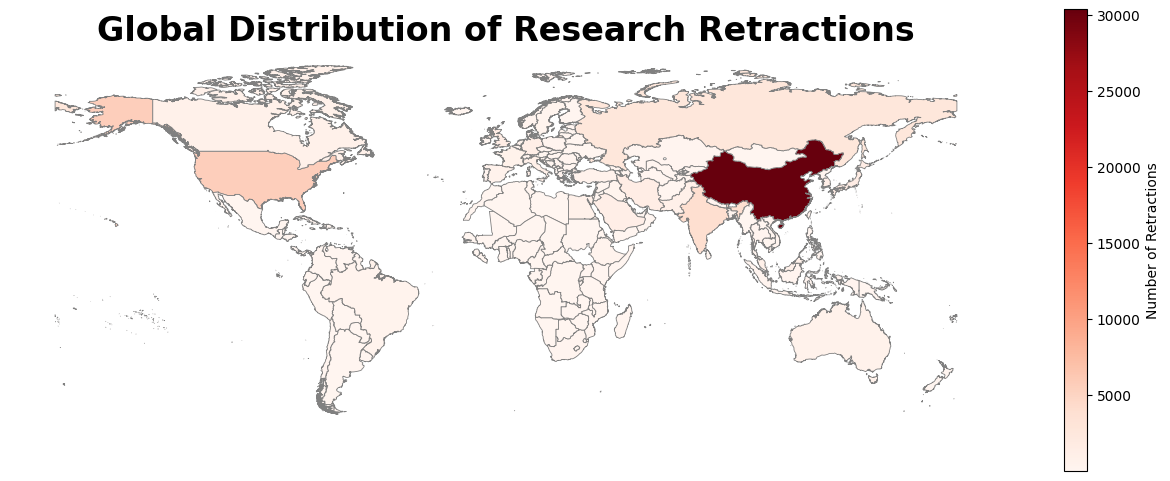

In [20]:
#ploting retation
fig,ax=plt.subplots(figsize=(16,10))
merge.plot(column="count",
           cmap="Reds",
           linewidth=0.6,
           ax=ax,
           edgecolor="Grey",
           legend=True,
           legend_kwds={
               "label": "Number of Retractions",
               "orientation": "vertical",
               "shrink": 0.6
           })

ax.axis("off")

# Add title
plt.title("Global Distribution of Research Retractions",
          fontsize=24,
          fontweight="bold")

# Add subtle background color
fig.patch.set_facecolor("white")

In [ ]:
merge["count"].quantile(0.75)

np.float64(37.5)

In [22]:
merge["Country_below_75_percentile"]=merge["count"]<merge["count"].quantile(0.75)
merge["Country_greater_75_percentile"]=merge["count"]>=merge["count"].quantile(0.75)

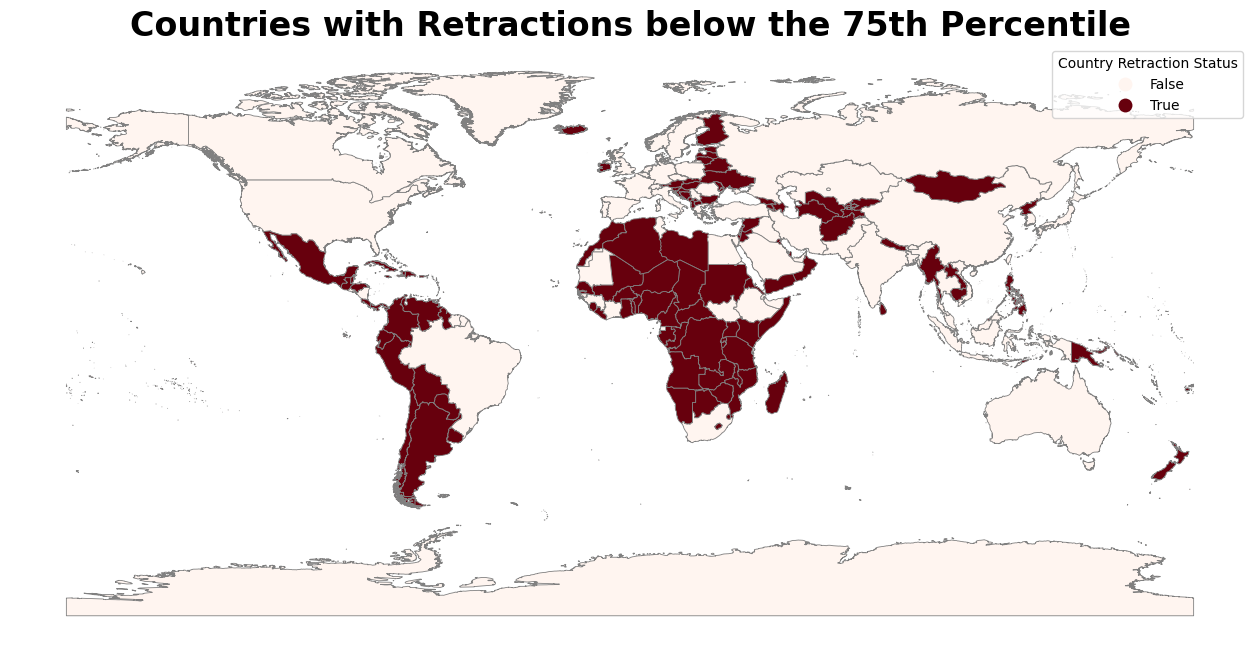

In [23]:
#plot for assuming that countries which are below 75 percentile  those countries has no much performance reaserch paper publication

fig , ax = plt.subplots(figsize=(16,10))
merge.plot(column="Country_below_75_percentile",
           cmap="Reds",
           ax=ax,
           linewidth=0.6,
           edgecolor="gray",
           legend=True,
           legend_kwds={
               "title": "Country Retraction Status" # Removed 'orientation' and 'shrink'
           })
ax.axis("off")

#title
plt.title("Countries with Retractions below the 75th Percentile",
          fontsize=24,
          fontweight="bold")
fig.patch.set_facecolor("white")

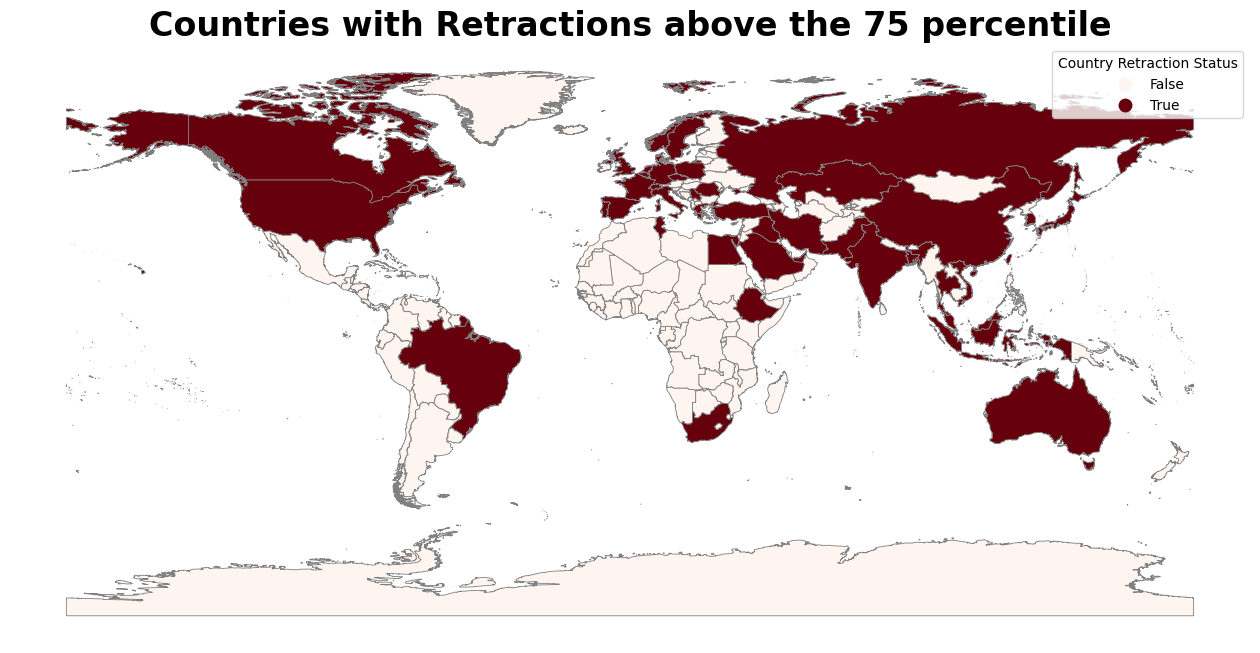

In [24]:
#greater 75 persentile(more paper more retaction)
fig,ax= plt.subplots(figsize=(16,10))

merge.plot(column="Country_greater_75_percentile",
           cmap="Reds",
           ax=ax,
           linewidth=0.6,
           edgecolor="gray",
           legend=True,
           legend_kwds={
               "title": "Country Retraction Status"}
           )
ax.axis("off")

# title
plt.title("Countries with Retractions above the 75 percentile",
          fontsize=24,
          fontweight="bold"
          )

# plt.title("More paper and More Retation ",
#           fontsize=15,
#           pad=25
#           )
fig.patch.set_facecolor("white")


# insights
Insights regarding retractions:

###Retraction Nature Distribution:
The dataset predominantly consists of full 'Retractions' (18,961), followed by 'Expression of concern' (1,057), 'Correction' (273), and a small number of 'Reinstatement' (32).
#As working with only retraction
###Geographical Distribution of Retractions:
 China stands out significantly with 13,209 retractions, which is higher than any other country. The top 10 countries by retraction count are:

* China: 13209 (which is greater then half of the total retraction)
* India: 1620
* United States of America: 1139
* Saudi Arabia: 935
* Pakistan: 542
* Iran: 459
* South Korea: 448
* Egypt: 415
* Ethiopia: 392
* United Kingdom: 327
###Skewed Distribution:
 The distribution of retractions across countries is highly skewed. While the mean number of retractions per country is around 157, the maximum is 13,209 (China), and 75% of countries have 36 or fewer retractions. This indicates that a few countries contribute disproportionately to the total number of retractions.

###75th Percentile Analysis:
The generated maps visually highlight countries with retraction counts above and below the 75th percentile. This provides a clear picture of which nations are global hotspots for research retractions and which have relatively fewer.


